In [1]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import tqdm

from qibo import (
    Circuit, 
    gates, 
    hamiltonians,
    symbols,
    construct_backend,
)

from scipy.stats import median_abs_deviation

from tncdr.targets.ansatze import TranspiledAnsatz, HardwareEfficient
from tncdr.evolutors.models import HybridSurrogate

def construct_circuit(nqubits: int, nlayers: int):
    """Conctruct a target quantum circuit."""
    c = Circuit(nqubits)
    for _ in range(nlayers):
        for q in range(nqubits):
            c.add(gates.RZ(q=q, theta=random.random()))
        [c.add(gates.CNOT(q0=q%nqubits, q1=(q+1)%nqubits)) for q in range(nqubits)]
    return c

def initial_state(nqubits: int):
    """Construct a random initial state."""
    c = Circuit(nqubits)
    for q in range(nqubits):
        c.add(gates.RY(q=q, theta=random.random()))
    return c

def set_seed(seed:int, backend=None):
    if backend is not None:
        backend.set_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

def qibo_ham_from_string(obs:str, backend):
    form = 1
    for i, pauli in enumerate(obs):
        form *= getattr(symbols, pauli)(i)
    ham = hamiltonians.SymbolicHamiltonian(form=form, backend=backend)
    return ham

def plot_benchmarks(values, errors, colors, labels):
    plt.figure(figsize=(7, 7 * 6/8))
    for (val, err, col, lab) in zip(values, errors, colors, labels):
        plt.errorbar(
            x=np.arange(3, len(val)+3, 1),
            y=val, 
            yerr=err,
            color=col,
            label=lab,
            marker="o",
            markersize=10,
            markeredgecolor='black',      
            capsize=5,
            ecolor="black"
        )
    plt.xlabel("Qubits", fontsize=12)
    plt.ylabel("Time [s]", fontsize=12)
    plt.yscale("log")
    plt.legend(fontsize=12)

In [2]:
def execute_benchmark(
    nqubits:int, 
    nlayers:int, 
    method_description:dict, 
    nruns:int, 
):

    obs = "Y" * nqubits
    
    if method_description.get("backend"):
        if method_description.get("platform"):
            backend = construct_backend(
                method_description.get("backend"),
                platform = method_description.get("platform"),
            )
        else:
            backend = construct_backend(
                method_description.get("backend"),
            )          
        ham = qibo_ham_from_string(obs, backend=backend)

    times = []
    for i in range(nruns):
        set_seed(i+1)
        # construct HDW efficient circuit
        # and initial state
        circ = construct_circuit(nqubits=nqubits, nlayers=nlayers)
        init_psi = initial_state(nqubits=nqubits)
            
        if method_description["mode"] == "hybrid_stab_mpo":
            ans = TranspiledAnsatz(original_circuit=circ)
            hs = HybridSurrogate(
                ansatz=ans,
                initial_state=init_psi,
                max_bond_dimension=method_description["bond_dim"],
            ) 
            # dry run
            expv, _ = hs.expectation_from_partition(
                observable=obs, replacement_probability=method_description["replacement_probability"]
            )
            it = time.time()
            expv, _ = hs.expectation_from_partition(
                observable=obs, replacement_probability=method_description["replacement_probability"]
            )
            times.append(time.time() - it)
        elif method_description["mode"] == "qibo":
            # dry run
            ham.expectation(
                backend.execute_circuit(
                    circ
                ).state()
            )
            it = time.time()
            ham.expectation(
                backend.execute_circuit(
                    circ
                ).state()
            )
            times.append(time.time() - it)
    return np.median(times[1:]), median_abs_deviation(times[1:])

In [3]:
def execute_bench(max_qubits, method_description):
    times, errs = [], []
    
    for q in tqdm.tqdm(range(3, max_qubits, 1)):
        val, err = execute_benchmark(
            nqubits=q, 
            nlayers=3, 
            nruns=5, 
            method_description=method_description, 
        )
        times.append(val)
        errs.append(err)
    return times, errs

In [4]:
method_list = [
    # {'mode': 'qibo', 'backend': 'numpy'},
    # {'mode': 'qibo', 'backend': 'qibojit', "platform": "numba"},
    # {'mode': 'hybrid_stab_mpo', 'replacement_probability': 0.7, "bond_dim": 2},
    # {'mode': 'hybrid_stab_mpo', 'replacement_probability': 0.7, "bond_dim": 256},
    {'mode': 'hybrid_stab_mpo', 'replacement_probability': 0.7, "bond_dim": 1024},
    {'mode': 'hybrid_stab_mpo', 'replacement_probability': 1., "bond_dim": 1024},
]

In [ ]:
values, errors = [], []
for method_config in method_list:
    vals, errs = execute_bench(
        max_qubits=35, 
        method_description=method_config, 
    )
    values.append(vals)
    errors.append(errs)

 34%|██████████████████████████████████████▏                                                                        | 11/32 [00:50<03:35, 10.29s/it]

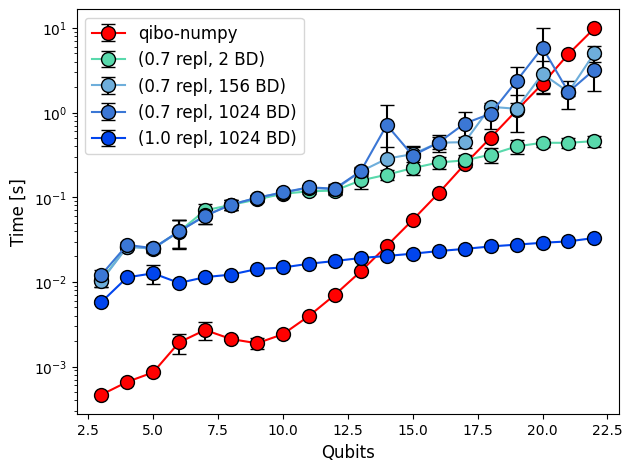

In [55]:
plot_benchmarks(
    values=values,
    errors=errors,
    colors=["red", "#59d9ac", "#6eaedb", "#3b77d5", "#0145ee"],
    labels=["qibo-numpy", "(0.7 repl, 2 BD)", "(0.7 repl, 156 BD)", "(0.7 repl, 1024 BD)", "(1.0 repl, 1024 BD)"]
)